In [74]:
# | default_exp datasets

# Dataset Definitions

> Defining interfaces for a few datasets [no experiments]
Notes: datasets YinYang and MNIST datasets are external datasets. We cite their source.

In [75]:
# | hide
import matplotlib.pyplot as plt
import matplotlib

In [76]:
# | export
import numpy as np
import torch
from torch.utils.data.dataset import Dataset
from torchvision import datasets, transforms
from torchvision.datasets import MNIST

In [77]:
# | hide
matplotlib.rc("figure", figsize=(5, 5))

In [78]:
# | export
class RectangularDataset(Dataset):
    "Binary dataset with classes in two rectangles across the y-axis"

    def __init__(
        self,
        num_samples=1_000,  # Dataset size
        num_extra_features=0,  # Number of additional Gaussian features
        negative_label=True,  # If true, returns labels as -1 and 1, else 0 and 1
    ):
        self.num_classes = 2
        self.num_samples = num_samples
        self.num_extra_features = num_extra_features

        # Number of samples per class
        samples_per_class = self.num_samples // self.num_classes

        # Define ranges for each class
        class_ranges = [[[-10, -0.1], [-10, 10]], [[0.1, 10], [0, 20]]]

        features_list = []
        labels_list = []

        for cl in range(self.num_classes):
            x1_range, x2_range = class_ranges[cl]

            # Efficiently sample from uniform distributions
            x1_data = torch.FloatTensor(samples_per_class).uniform_(*x1_range)
            x2_data = torch.FloatTensor(samples_per_class).uniform_(*x2_range)

            # Create extra_data only if num_extra_features > 0
            if self.num_extra_features > 0:
                extra_data = torch.FloatTensor(
                    samples_per_class, num_extra_features
                ).normal_(mean=0, std=0.01)
                features_list.append(
                    torch.stack(
                        [x1_data.unsqueeze(1), x2_data.unsqueeze(1), extra_data], dim=1
                    ).squeeze(-1)
                )
            else:
                features_list.append(torch.stack([x1_data, x2_data], dim=1))

            if negative_label:
                lbl = torch.full((samples_per_class, 1), -1.0 if cl == 0 else 1.0)
            else:
                lbl = torch.full((samples_per_class, 1), 0 if cl == 0 else 1.0)

            labels_list.append(lbl)

        self.features = torch.cat(features_list, dim=0).float()
        self.labels = torch.cat(labels_list, dim=0)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        input = self.features[idx]
        label = self.labels[idx]

        return input, label

    def __str__(self) -> str:
        return "rectangular"

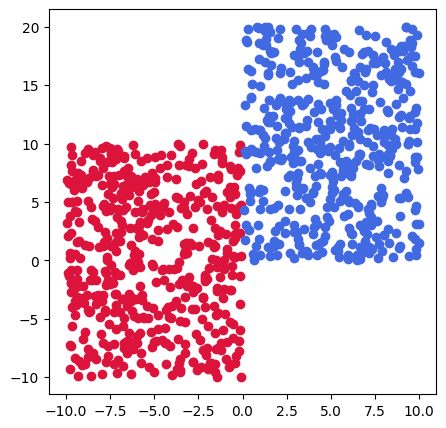

In [79]:
# Define dataset
dataset = RectangularDataset(num_samples=1000, negative_label=False)

# Plot data
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 0].T, color="crimson", label="0"
)
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 1].T, color="royalblue", label="1"
)

In [80]:
# | export
class YinYangDataset(Dataset):
    """
    3-way classification dataset with classes in YinYang form, sourced from: \\
    https://github.com/lkriener/yin_yang_data_set
    """

    def __init__(
        self,
        num_samples=1000,  # Dataset size
        seed=42,  # Randomness seed
        transform=None,  # Torch transforms
        r_small=0.1,
        r_big=0.5,
    ):
        super().__init__()
        # using a numpy RNG to allow compatibility to other deep learning frameworks
        self.rng = np.random.RandomState(seed)
        self.transform = transform
        self.r_small = r_small
        self.r_big = r_big
        self.features = []
        self.labels = []
        self.class_names = ["yin", "yang", "dot"]
        for i in range(num_samples):
            # keep num of class instances balanced by using rejection sampling
            # choose class for this sample
            goal_class = self.rng.randint(3)
            x, y, c = self.get_sample(goal=goal_class)
            # add mirrod axis values
            x_flipped = 1.0 - x
            y_flipped = 1.0 - y

            # val = np.array([x, y, x_flipped, y_flipped])
            val = np.array([x, y])
            self.features.append(val)
            self.labels.append(c)

        self.features = torch.FloatTensor(np.asarray(self.features))
        self.labels = torch.FloatTensor(self.labels).unsqueeze(1)

    def get_sample(self, goal=None):
        # sample until goal is satisfied
        found_sample_yet = False
        while not found_sample_yet:
            # sample x,y coordinates
            x, y = self.rng.rand(2) * 2.0 * self.r_big
            # check if within yin-yang circle
            if np.sqrt((x - self.r_big) ** 2 + (y - self.r_big) ** 2) > self.r_big:
                continue
            # check if they have the same class as the goal for this sample
            c = self.which_class(x, y)
            if goal is None or c == goal:
                found_sample_yet = True
                break

        return x, y, c

    def which_class(self, x, y):
        # equations inspired by
        # https://link.springer.com/content/pdf/10.1007/11564126_19.pdf
        d_right = self.dist_to_right_dot(x, y)
        d_left = self.dist_to_left_dot(x, y)
        criterion1 = d_right <= self.r_small
        criterion2 = d_left > self.r_small and d_left <= 0.5 * self.r_big
        criterion3 = y > self.r_big and d_right > 0.5 * self.r_big
        is_yin = criterion1 or criterion2 or criterion3
        is_circles = d_right < self.r_small or d_left < self.r_small
        if is_circles:
            return 2
        return int(is_yin)

    def dist_to_right_dot(self, x, y):
        return np.sqrt((x - 1.5 * self.r_big) ** 2 + (y - self.r_big) ** 2)

    def dist_to_left_dot(self, x, y):
        return np.sqrt((x - 0.5 * self.r_big) ** 2 + (y - self.r_big) ** 2)

    def __getitem__(self, index):
        sample = (self.features[index], self.labels[index])
        if self.transform:
            sample = self.transform(sample)
        return sample

    def __len__(self):
        return len(self.labels)

    def __str__(self) -> str:
        return "yinyang"

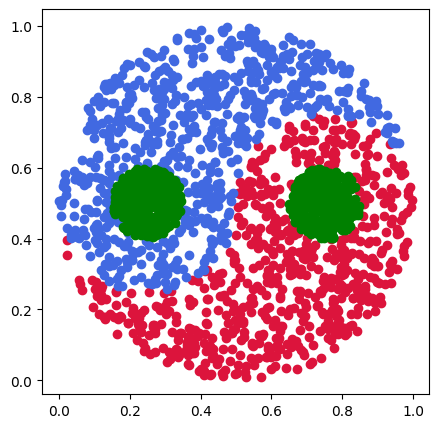

In [81]:
# Define dataset
dataset = YinYangDataset(num_samples=2000)

# Plot data
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 0].T, color="crimson", label="0"
)
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 1].T, color="royalblue", label="1"
)
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 2].T, color="green", label="2"
)

In [82]:
# | export
class YinYangBinaryDataset(Dataset):
    """
    Binarized dataset with classes in YinYang form, sourced from: \\
    https://github.com/lkriener/yin_yang_data_set
    """

    def __init__(
        self,
        num_samples=1000,  # Dataset size
        seed=42,  # Randomness seed
        transform=None,  # Torch transforms
        negative_label=True,  # If true, returns labels as -1 and 1, else 0 and 1
        r_small=0.1,
        r_big=0.5,
    ):
        super().__init__()
        # using a numpy RNG to allow compatibility to other deep learning frameworks
        self.rng = np.random.RandomState(seed)
        self.transform = transform
        self.r_small = r_small
        self.r_big = r_big
        self.features = []
        self.labels = []
        self.class_names = ["yin", "yang", "dot"]
        for i in range(num_samples):
            # keep num of class instances balanced by using rejection sampling
            # choose class for this sample
            goal_class = self.rng.randint(2)
            x, y, c = self.get_sample(goal=goal_class)
            # add mirrod axis values
            x_flipped = 1.0 - x
            y_flipped = 1.0 - y

            if negative_label and c == 0:
                c = -1

            # val = np.array([x, y, x_flipped, y_flipped])
            val = np.array([x, y])
            self.features.append(val)
            self.labels.append(c)

        self.features = torch.FloatTensor(np.asarray(self.features))
        self.labels = torch.FloatTensor(self.labels).unsqueeze(1)

    def get_sample(self, goal=None):
        # sample until goal is satisfied
        found_sample_yet = False
        while not found_sample_yet:
            # sample x,y coordinates
            x, y = self.rng.rand(2) * 2.0 * self.r_big
            # check if within yin-yang circle
            if np.sqrt((x - self.r_big) ** 2 + (y - self.r_big) ** 2) > self.r_big:
                continue
            # check if they have the same class as the goal for this sample
            c = self.which_class(x, y)
            if goal is None or c == goal:
                found_sample_yet = True
                break

        # if c == 0:
        #     c == -1

        return x, y, c

    def which_class(self, x, y):
        # equations inspired by
        # https://link.springer.com/content/pdf/10.1007/11564126_19.pdf
        d_right = self.dist_to_right_dot(x, y)
        d_left = self.dist_to_left_dot(x, y)
        criterion1 = d_right <= self.r_small
        criterion2 = d_left > self.r_small and d_left <= 0.5 * self.r_big
        criterion3 = y > self.r_big and d_right > 0.5 * self.r_big
        is_yin = criterion1 or criterion2 or criterion3
        is_circles = d_right < self.r_small or d_left < self.r_small
        if is_circles:
            return 2
        return int(is_yin)

    def dist_to_right_dot(self, x, y):
        return np.sqrt((x - 1.5 * self.r_big) ** 2 + (y - self.r_big) ** 2)

    def dist_to_left_dot(self, x, y):
        return np.sqrt((x - 0.5 * self.r_big) ** 2 + (y - self.r_big) ** 2)

    def __getitem__(self, index):
        sample = (self.features[index], self.labels[index])
        if self.transform:
            sample = self.transform(sample)
        return sample

    def __len__(self):
        return len(self.labels)

    def __str__(self) -> str:
        return "yinyang"

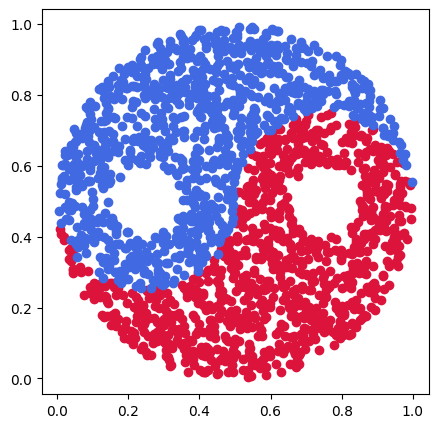

In [83]:
# Define dataset
dataset = YinYangBinaryDataset(num_samples=2000, negative_label=False)

# Plot data
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 0].T, color="crimson", label="0"
)
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 1].T, color="royalblue", label="1"
)

In [84]:
# | export
class MNISTDataset:
    """Simple wrapper around MNIST dataset"""

    default_transform = transforms.Compose(
                [
                    transforms.ToTensor(),  # first, convert image to PyTorch tensor
                    transforms.Normalize((0.1307,), (0.3081,)),  # normalize inputs
                ]
            )

    def __init__(self,
                 seed=42, # Randomness seed
                 transform=default_transform, # Torch transforms, uses default MNIST transform
                 root="/mnt/datasets/", # Dataset location
                 train=True, # Train or test dataset
                 ):
                    
        self.data = datasets.MNIST(
            root=root, 
            train=train, 
            download=True, 
            transform=transform
        ).data

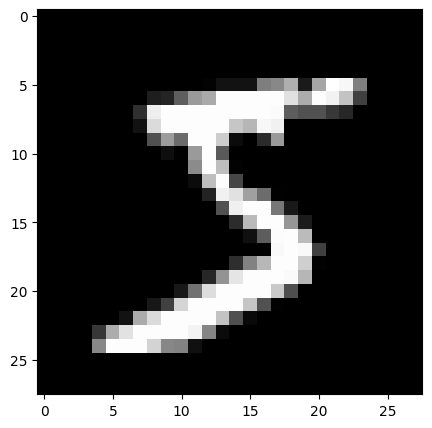

In [85]:
dataset = MNISTDataset()
plt.imshow(dataset.data[0], cmap="gray")